In [96]:
#imports
import re
import csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

In [97]:
input_file = "Raw_data/output_2025-05-03_CB_test.log"
output_file = "CSVs/cell_balance_test_05-03.csv"

with open(input_file, "r") as f:
    content = f.read()

# Split into individual blocks
blocks = content.split("Time: ")
parsed_data = []

for block in blocks[1:]:  # skip the first split part (before first "Time:")
    time_match = re.match(r"(\d+)", block)
    time = time_match.group(1) if time_match else ""

    data = {
        "Time": time,
    }

    # Voltage summary
    summary_keys = ["total_v", "max_v", "min_v", "avg_v"]
    for key in summary_keys:
        match = re.search(rf"{key}:\s*([\d.]+)", block)
        data[key] = match.group(1) if match else ""

    # max-min
    match = re.search(r"max-min:\s*([\d.]+)", block)
    data["max-min"] = match.group(1) if match else ""

    # Cell voltages
    for i in range(1, 15):
        match = re.search(rf"C{i}=([\d.]+)V", block)
        data[f"C{i}"] = match.group(1) if match else ""

    # Temperature summary
    for key in ["max_temp", "min_temp", "avg_temp"]:
        match = re.search(rf"{key}:\s*([\d.]+)", block)
        data[key] = match.group(1) if match else ""

    # Error flags
    for key in ["undervoltage", "overvoltage", "pec", "overtemperature", "openwire", "openwire_temp"]:
        match = re.search(rf"{key}:\s*(\d+)", block)
        data[key] = match.group(1) if match else ""

    # Current
    match = re.search(r"Current:\s*([\d.]+)", block)
    data["Current"] = match.group(1) if match else ""
        
    # SOC
    match = re.search(r"SOC:\s*([\d.]+)", block)
    data["SOC"] = match.group(1) if match else ""

    parsed_data.append(data)

# Write to CSV
with open(output_file, "w", newline="") as csvfile:
    fieldnames = parsed_data[0].keys()
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(parsed_data)

print(f"CSV saved as: {output_file}")


CSV saved as: CSVs/cell_balance_test_05-03.csv


In [98]:
df = pd.read_csv("CSVs/cell_balance_test_05-03.csv")
df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

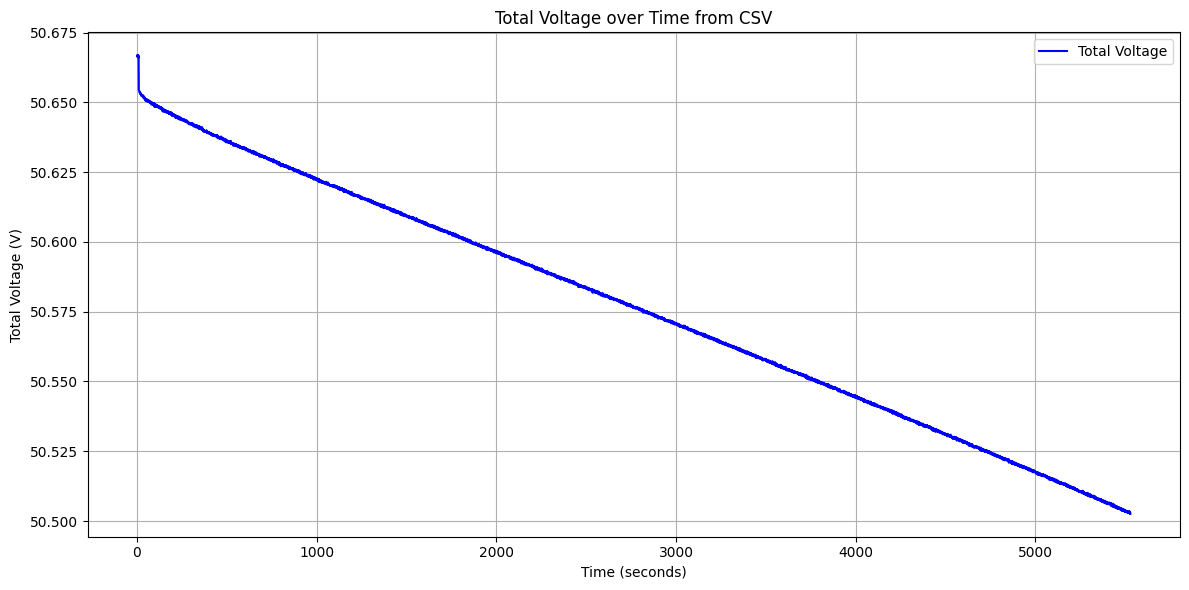

In [99]:
# Ensure numeric types for plotting
df["total_v"] = pd.to_numeric(df["total_v"], errors="coerce")

# Drop rows with missing values just in case
df = df.dropna(subset=["Time", "total_v"])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Time"]/1000, df["total_v"], label="Total Voltage", color="blue")
plt.xlabel("Time (seconds)")
plt.ylabel("Total Voltage (V)")
plt.title("Total Voltage over Time from CSV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

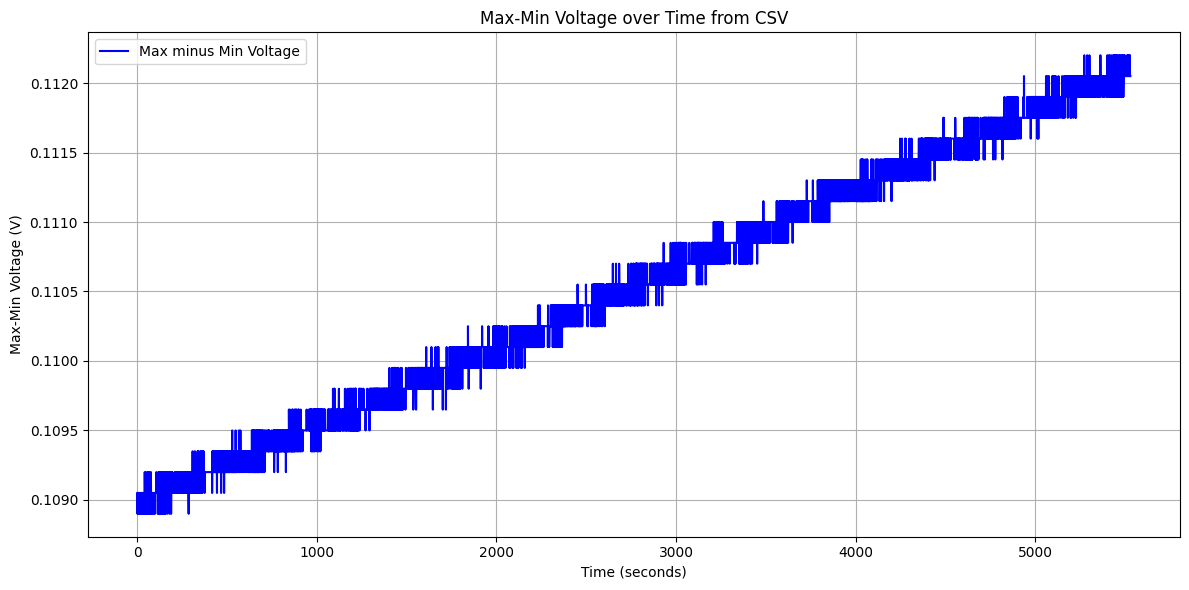

In [100]:
# Ensure numeric types for plotting
df["max-min"] = pd.to_numeric(df["max-min"], errors="coerce")

# Drop rows with missing values just in case
df = df.dropna(subset=["Time", "max-min"])

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df["Time"]/1000, df["max-min"], label="Max minus Min Voltage", color="blue")
plt.xlabel("Time (seconds)")
plt.ylabel("Max-Min Voltage (V)")
plt.title("Max-Min Voltage over Time from CSV")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

C1 slope: -0.0000025537
C2 slope: -0.0000035050
C3 slope: -0.0000026379
C4 slope: -0.0000033960
C5 slope: -0.0000025870
C6 slope: -0.0000025899
C7 slope: -0.0000026061
C8 slope: -0.0000008773
C9 slope: -0.0000009151
C10 slope: -0.0000009158
C11 slope: -0.0000007562
C12 slope: -0.0000006839
C13 slope: -0.0000013249
C14 slope: -0.0000010595


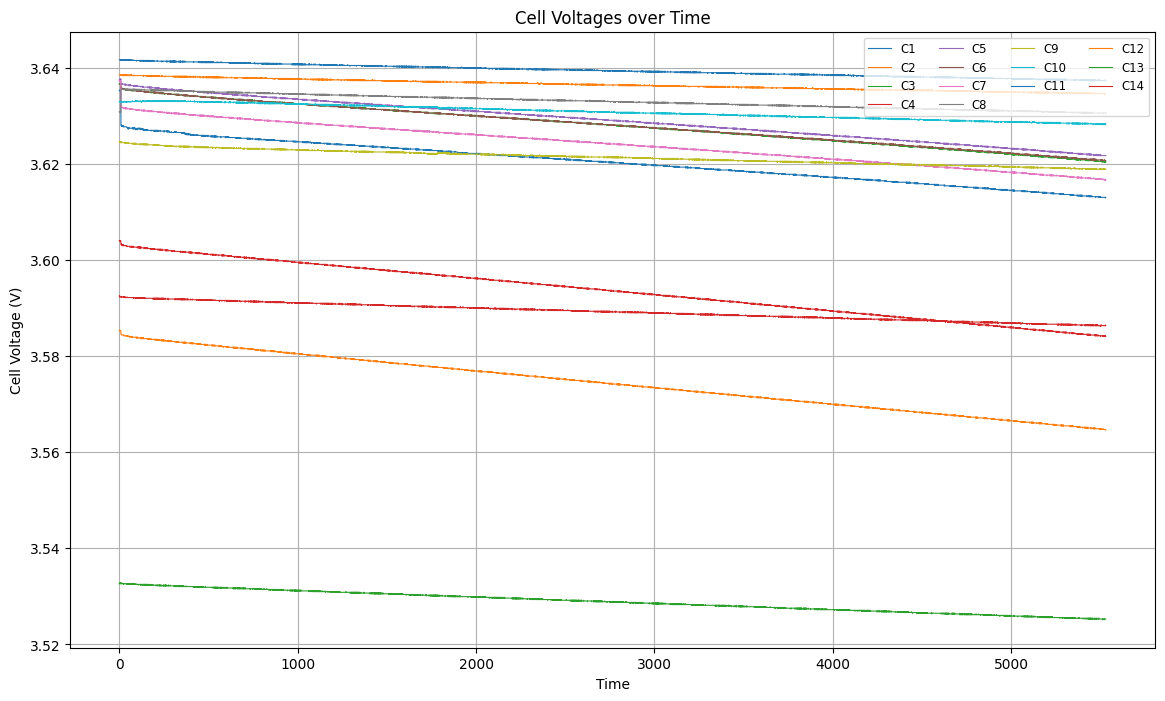

<Figure size 1400x800 with 0 Axes>

In [101]:
for i in range(1, 15):
    df[f"C{i}"] = pd.to_numeric(df[f"C{i}"], errors="coerce")

df = df.dropna(subset=["Time"])

plt.figure(figsize=(14, 8))
for j in range(1, 15):
    plt.plot(df["Time"]/1000, df[f"C{j}"], label=f"C{j}", linewidth=0.8)
    slope, intercept, r_value, p_value, std_err = stats.linregress(df["Time"]/1000, df[f"C{j}"])
    print(f"C{j} slope: {slope:.10f}")
plt.xlabel("Time")
plt.ylabel("Cell Voltage (V)")
plt.title("Cell Voltages over Time")
plt.legend(ncol=4, fontsize="small", loc="upper right")
plt.grid(True)
plt.axes
plt.figure(figsize=(14, 8))
# plt.ylim((2.5,4.2))
# plt.tight_layout()
plt.show()

0.02220000000000022


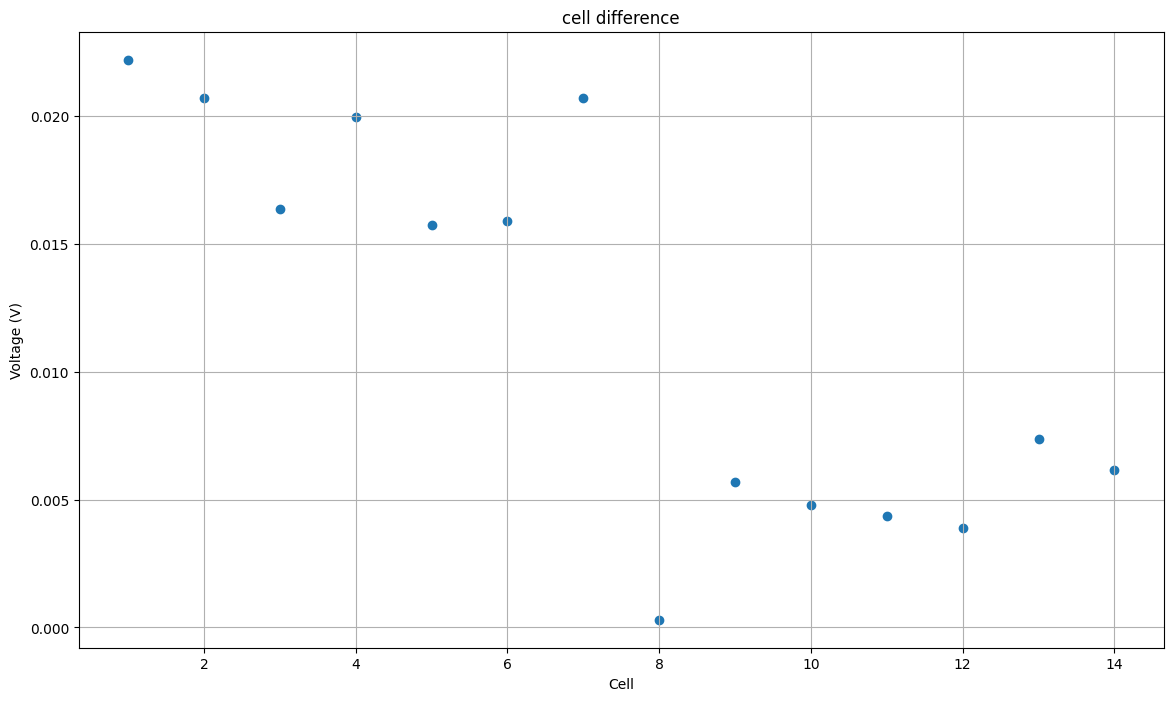

In [102]:
plt.figure(figsize=(14, 8))
print(df[f"C{1}"][0] - df[f"C{1}"].iloc[-1])

line = [df[f"C{j}"][0] - df[f"C{j}"].iloc[-1] for j in range(1, 15)]
x = np.arange(1, 15)
plt.scatter(x, line)

plt.xlabel("Cell")
plt.ylabel("Voltage (V)")
plt.title("cell difference")
# plt.legend(ncol=4, fontsize="small", loc="upper right")
plt.grid(True)
plt.axes
plt.show()

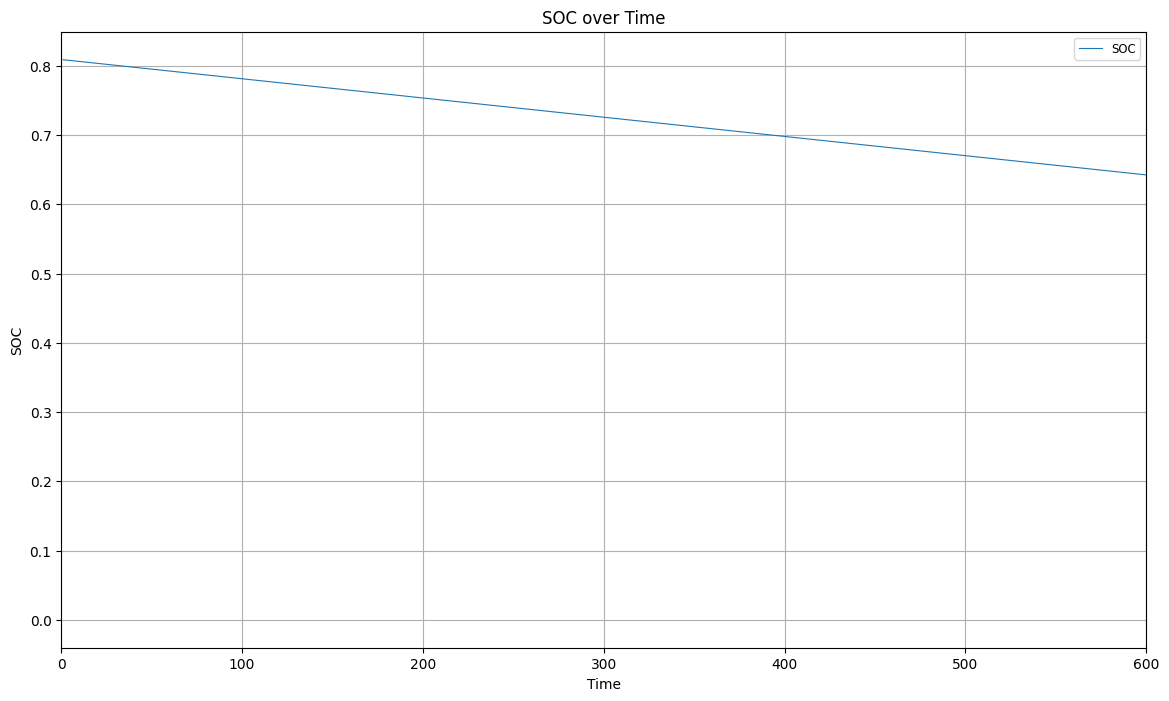

SOC slope: nan


In [107]:

df["SOC"] = pd.to_numeric(df["SOC"], errors="coerce")

plt.figure(figsize=(14, 8))
plt.plot(df["Time"]/1000, df["SOC"], label="SOC", linewidth=0.8)
plt.xlabel("Time")
plt.ylabel("SOC")
plt.title("SOC over Time")
plt.legend(ncol=4, fontsize="small", loc="upper right")
plt.grid(True)
plt.axes
plt.xlim((0, 600))
# plt.tight_layout()
plt.show()

slope, intercept, r_value, p_value, std_err = stats.linregress(df["Time"]/1000, df["SOC"])
print(f"SOC slope: {slope:.10f}")